In [1]:
import sys
from pathlib import Path

src_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), None)
if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory in current path or parent directories.")

sys.path.insert(0, str(src_path))
print(f"Added to sys.path: {src_path}")

Added to sys.path: /users/eleves-b/2023/keyvan.attarian/RL_project


In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import time

from src.dvn.agent import DVNAgent1P
from src.blockblast.block_blast_3p_env import BlockBlast3PEnv

In [10]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [11]:
gamma = 0.99
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = BlockBlast3PEnv(lookahead_gamma=gamma)
agent = DVNAgent1P(device=device)
agent.load_model("../checkpoints/dvn_final_bestpourlemoment.pt")

print("Device:", device)

Device: cuda


In [12]:
class RoundPlanner3P:
    def __init__(self, gamma, agent, debug=False, name="planner"):
        self.gamma = gamma
        self.agent = agent
        self.plan_actions = []
        self.debug = debug
        self.name = name
        self.round_id = 0

    def reset_round_plan(self):
        self.plan_actions = []

    def _action_to_text(self, env, action):
        piece = action // (env.grid_size * env.grid_size)
        pos = action % (env.grid_size * env.grid_size)
        row = pos // env.grid_size
        col = pos % env.grid_size
        return f"piece={piece}, row={row}, col={col}, action={action}"

    def _build_new_round_plan(self, env):
        candidates = env.get_t_plus_3_candidates(self.gamma)

        if len(candidates) == 0:
            valid_flat = env.valid_placements.reshape(-1)
            valid_actions = np.flatnonzero(valid_flat)
            if len(valid_actions) == 0:
                if self.debug:
                    print(f"[{self.name}] No candidate and no valid action.")
                return None

            fallback = int(np.random.choice(valid_actions))
            if self.debug:
                print(f"[{self.name}] Fallback single action: {self._action_to_text(env, fallback)}")
            return [fallback]

        boards = np.stack([c["state_t_plus_3"] for c in candidates]).astype(np.float32)
        cum3 = np.array([c["cumulative_reward_3steps"] for c in candidates], dtype=np.float32)

        with torch.no_grad():
            x = torch.from_numpy(boards).to(self.agent.device)
            v = self.agent.policy_net(x).squeeze(-1).detach().cpu().numpy().astype(np.float32)

        g = cum3 + (self.gamma ** 3) * v
        best_idx = int(np.argmax(g))

        chosen = candidates[best_idx]["actions"]
        actions = [
            int(p * env.grid_size * env.grid_size + r * env.grid_size + c)
            for (p, r, c) in chosen
        ]

        if self.debug:
            self.round_id += 1
            order = candidates[best_idx]["order"]
            print(f"\n[{self.name}] Round {self.round_id}")
            print(f"[{self.name}] Candidates: {len(candidates)} | Best G: {g[best_idx]:.3f}")
            print(f"[{self.name}] Best order: {order}")
            print(f"[{self.name}] Planned actions:")
            for i, a in enumerate(actions, start=1):
                print(f"  {i}. {self._action_to_text(env, a)}")

        return actions

    def select_action(self, env):
        if len(self.plan_actions) == 0:
            new_plan = self._build_new_round_plan(env)
            if new_plan is None:
                return None
            self.plan_actions = new_plan

        action = self.plan_actions.pop(0)

        # Safety check in case of desync: rebuild once.
        if env.valid_placements.reshape(-1)[action] == 0:
            if self.debug:
                print(f"[{self.name}] Desync detected on action {action}, rebuilding plan.")
            self.plan_actions = []
            new_plan = self._build_new_round_plan(env)
            if new_plan is None:
                return None
            self.plan_actions = new_plan
            action = self.plan_actions.pop(0)

        if self.debug:
            print(f"[{self.name}] Play -> {self._action_to_text(env, action)} | Remaining in round: {len(self.plan_actions)}")

        return action

In [13]:
num_episodes = 200
max_steps_per_episode = 200

returns = []
lengths = []

# Keep evaluation mostly quiet. Set debug=True if you want full logs.
planner = RoundPlanner3P(gamma=gamma, agent=agent, debug=False, name="eval")

for _ in tqdm(range(num_episodes), desc="3P DVN evaluation"):
    obs, _ = env.reset()
    planner.reset_round_plan()
    episode_return = 0.0

    for step in range(max_steps_per_episode):
        action = planner.select_action(env)
        if action is None:
            break

        obs, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward

        if terminated or truncated:
            break

    returns.append(episode_return)
    lengths.append(step + 1)

returns = np.array(returns, dtype=np.float32)
lengths = np.array(lengths, dtype=np.int32)

print(f"Average Return: {returns.mean():.2f} +- {returns.std():.2f}")
print(f"Average Episode Length: {lengths.mean():.2f} +- {lengths.std():.2f}")

3P DVN evaluation:   0%|          | 0/200 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(returns, bins=20, alpha=0.8)
plt.title("3P Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(lengths, bins=20, alpha=0.8)
plt.title("3P Episode Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

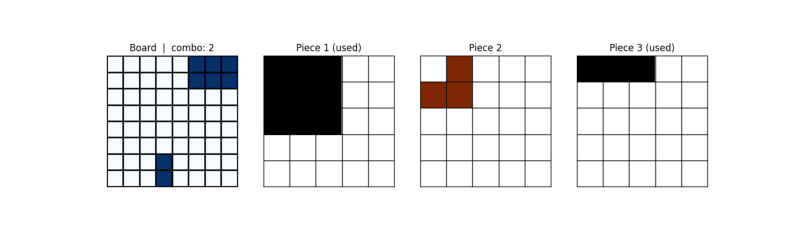

[vis] Play -> piece=1, row=0, col=3, action=67 | Remaining in round: 0


In [ ]:
env_vis = BlockBlast3PEnv(render_mode="rgb_array", lookahead_gamma=gamma)
obs, _ = env_vis.reset()

# Debug ON for visual run so you can follow each 3-step plan.
planner_vis = RoundPlanner3P(gamma=gamma, agent=agent, debug=True, name="vis")
planner_vis.reset_round_plan()

total_reward = 0.0
steps = 25

for t in range(steps):
    img = env_vis.render()
    clear_output(wait=True)
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    action = planner_vis.select_action(env_vis)
    if action is None:
        print("No valid action available.")
        break

    obs, reward, terminated, truncated, _ = env_vis.step(action)
    total_reward += reward
    print(f"Step {t+1} | Reward: {reward:.2f} | Total: {total_reward:.2f}")

    time.sleep(1)
    if terminated or truncated:
        print("Episode finished.")
        break

env_vis.close()